In [1]:
import pandas as pd
df = pd.read_excel("job-ads.xlsx")
df .head()

,Job_Title,Company,Job_Text,Link
0,Working Student Intelligent Automation,METAPOTT GMBH,As a working student (m/f/d) in the field of I...,https://de.indeed.com/viewjob?jk=18f62fc6dbd00099
1,Working Student HR Data / Analytics,ASML Germany GMBH,Your tasks\n\nAs a working student HR Data & A...,Working Student HR Data / Analytics Jobs - May...
2,Working Student (m/f/d) for Customer Integrati...,WTT CampusONE GMBH,Your tasks:\n\nYou will support our IT and pro...,"IT Working Student Jobs | Find 1,000 vacancies..."
3,Working Student (m/f/d) Innovation & Digital S...,Viastore Group,Your tasks\nYou will actively support our inno...,"IT Working Student Jobs | Find 1,000 vacancies..."
4,Working student Operational Technology OT Devices,Schleswig-Holstein Network,"Your tasks\nSupport in the provisioning, suppo...","IT Working Student Jobs | Find 1,000 vacancies..."


In [2]:
df.shape

(6, 4)

In [3]:
df.columns

Index(['Job_Title', 'Company', 'Job_Text', 'Link'], dtype='str')

In [4]:
df["cleaned_text"] = df["Job_Text"].str.lower()

df[["Job_Title", "Company", "cleaned_text"]].head()

,Job_Title,Company,cleaned_text
0,Working Student Intelligent Automation,METAPOTT GMBH,as a working student (m/f/d) in the field of i...
1,Working Student HR Data / Analytics,ASML Germany GMBH,your tasks\n\nas a working student hr data & a...
2,Working Student (m/f/d) for Customer Integrati...,WTT CampusONE GMBH,your tasks:\n\nyou will support our it and pro...
3,Working Student (m/f/d) Innovation & Digital S...,Viastore Group,your tasks\nyou will actively support our inno...
4,Working student Operational Technology OT Devices,Schleswig-Holstein Network,"your tasks\nsupport in the provisioning, suppo..."


In [7]:
# Import NLTK tools needed for text preprocessing:
# stopwords for removal of frequent and uninformative words, word tokenization for splitting text into words
# and WordNetLemmatizer for reducing word forms to their base form.

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\user\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [8]:
# segment input character sequence into "useful" tokens.

df["tokens"] = df["cleaned_text"].apply(lambda x: word_tokenize(str(x)))

df[["Job_Title", "tokens"]].head()

,Job_Title,tokens
0,Working Student Intelligent Automation,"[as, a, working, student, (, m/f/d, ), in, the..."
1,Working Student HR Data / Analytics,"[your, tasks, as, a, working, student, hr, dat..."
2,Working Student (m/f/d) for Customer Integrati...,"[your, tasks, :, you, will, support, our, it, ..."
3,Working Student (m/f/d) Innovation & Digital S...,"[your, tasks, you, will, actively, support, ou..."
4,Working student Operational Technology OT Devices,"[your, tasks, support, in, the, provisioning, ..."


In [9]:
# Remove common and frequent English stop words from the tokens.

df["tokens_no_stopwords"] = df["tokens"].apply(
    lambda tokens: [word for word in tokens if word not in stop_words and len(word) > 2]
)

df[["Job_Title", "tokens_no_stopwords"]].head()

,Job_Title,tokens_no_stopwords
0,Working Student Intelligent Automation,"[working, student, m/f/d, field, intelligent, ..."
1,Working Student HR Data / Analytics,"[tasks, working, student, data, analytics, par..."
2,Working Student (m/f/d) for Customer Integrati...,"[tasks, support, product, team, technical, set..."
3,Working Student (m/f/d) Innovation & Digital S...,"[tasks, actively, support, innovation, managem..."
4,Working student Operational Technology OT Devices,"[tasks, support, provisioning, support, manage..."


In [11]:
# Lemmatize the tokens to reduce words to their base form.

df["lemmatized_tokens"] = df["tokens_no_stopwords"].apply(
    lambda tokens: [lemmatizer.lemmatize(word) for word in tokens]
)

df[["Job_Title", "lemmatized_tokens"]].head()

,Job_Title,lemmatized_tokens
0,Working Student Intelligent Automation,"[working, student, m/f/d, field, intelligent, ..."
1,Working Student HR Data / Analytics,"[task, working, student, data, analytics, part..."
2,Working Student (m/f/d) for Customer Integrati...,"[task, support, product, team, technical, setu..."
3,Working Student (m/f/d) Innovation & Digital S...,"[task, actively, support, innovation, manageme..."
4,Working student Operational Technology OT Devices,"[task, support, provisioning, support, managem..."


In [12]:
# combine the lemmatized tokens into one final cleaned text column.

df["final_cleaned_text"] = df["lemmatized_tokens"].apply(lambda tokens: " ".join(tokens))

df[["Job_Title", "Company", "final_cleaned_text"]].head()

,Job_Title,Company,final_cleaned_text
0,Working Student Intelligent Automation,METAPOTT GMBH,working student m/f/d field intelligent automa...
1,Working Student HR Data / Analytics,ASML Germany GMBH,task working student data analytics participat...
2,Working Student (m/f/d) for Customer Integrati...,WTT CampusONE GMBH,task support product team technical setup supp...
3,Working Student (m/f/d) Innovation & Digital S...,Viastore Group,task actively support innovation management ev...
4,Working student Operational Technology OT Devices,Schleswig-Holstein Network,task support provisioning support management e...


In [16]:
# Count the most frequent and common words across all job advertisements.

from collections import Counter

all_words = " ".join(df["final_cleaned_text"]).split()
word_counts = Counter(all_words)

word_counts.most_common(15)

[('support', 21),
 ('data', 19),
 ('customer', 15),
 ('work', 14),
 ('task', 11),
 ('working', 10),
 ('business', 10),
 ('process', 10),
 ('project', 9),
 ('management', 8),
 ('technical', 8),
 ('experience', 8),
 ('etc', 8),
 ('tool', 8),
 ('team', 8)]

In [22]:
# Add domain-specific stop words that are frequent but not useful for analysis.

extra_stop_words = {
    "working", "student", "task", "tasks", "etc", "your", "you", "will",
    "support", "work", "e", "g", "eg", "e.g"
}

all_words = [
    word for word in " ".join(df["final_cleaned_text"]).split()
    if word not in extra_stop_words
]

word_counts = Counter(all_words)

common_words_df = pd.DataFrame(word_counts.most_common(15), columns=["word", "frequency"])

common_words_df

,word,frequency
0,data,19
1,customer,15
2,business,10
3,process,10
4,project,9
5,management,8
6,technical,8
7,experience,8
8,tool,8
9,team,8


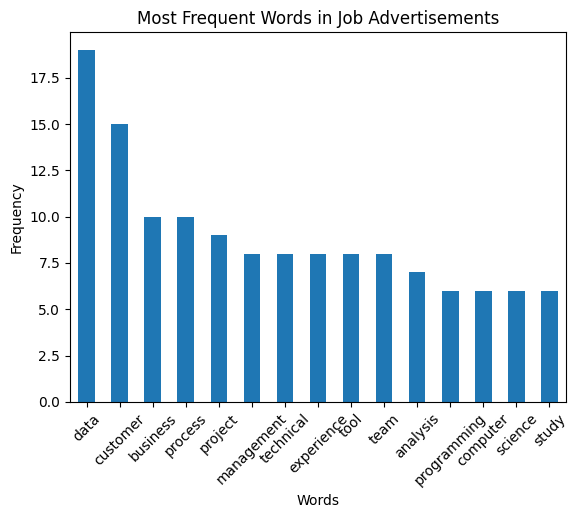

In [24]:
# present the most frequent words in a bar chart.

import matplotlib.pyplot as plt

common_words_df.plot(kind="bar", x="word", y="frequency", legend=False)

plt.title("Most Frequent Words in Job Advertisements")
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
plt.show()


### Interpretation of Word Frequency Results

The word frequency analysis shows that the most common words found in the collected job advertisements were mainly related to IT, data science, business processes, and projects. Frequent terms such as data, customer, business, process, project, and management suggest that these working student positions often focus on supporting data related tasks, improving business workflows, and contributing to project based work.

Technical and analytical skills also appear frequently through words such as technical, analysis, programming, computer, and science. Overall, the results indicate that the selected job ads combine technical knowledge with business oriented tasks, customer related responsibilities, and teamwork.

In [26]:
# Count selected skills and tools in the job advertisements more accurately.

import re

skills = [
    "python", "sql", "excel", "power bi", "tableau",
    "data", "analytics", "analysis", "programming",
    "automation", "ai", "low code", "process mining",
    "communication", "teamwork", "project management",
    "business", "customer"
]

skill_counts = {}

for skill in skills:
    pattern = r"\b" + re.escape(skill) + r"\b"
    skill_counts[skill] = df["Job_Text"].str.lower().apply(
        lambda text: len(re.findall(pattern, str(text)))
    ).sum()

skill_counts_df = pd.DataFrame(skill_counts.items(), columns=["skill", "frequency"])
skill_counts_df = skill_counts_df.sort_values(by="frequency", ascending=False)

skill_counts_df

,skill,frequency
5,data,20
17,customer,12
16,business,10
8,programming,6
7,analysis,5
9,automation,5
13,communication,4
0,python,3
10,ai,3
12,process mining,2


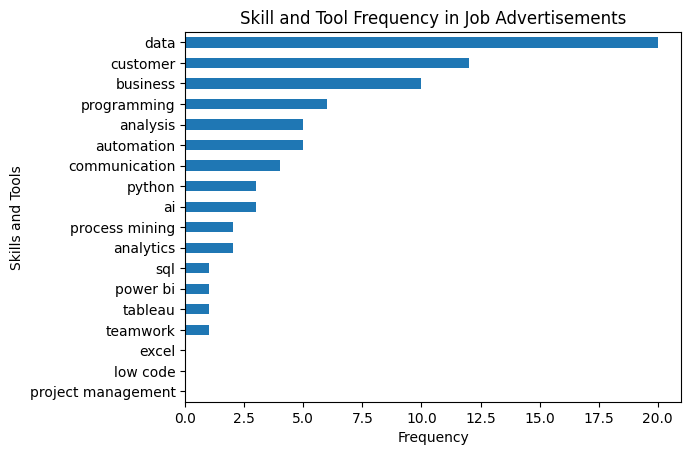

In [28]:
# Present the skill frequency results in a horizontal bar chart.

skill_counts_df.plot(kind="barh", x="skill", y="frequency", legend=False)

plt.title("Skill and Tool Frequency in Job Advertisements")
plt.xlabel("Frequency")
plt.ylabel("Skills and Tools")
plt.gca().invert_yaxis()
plt.show()

### Interpretation of Skill Frequency Results

The skill frequency analysis shows that the most frequent topics in the job advertisements are related to data, customers, business, programming, analysis, automation, and communication. This suggests that the selected working student positions are strongly connected to data related tasks, business processes, and technical support.

Specific tools and technical skills such as Python, SQL, Power BI, Tableau, Excel, AI, and process mining also appear in the job ads. However, general terms such as data, business, and customer appear more often, which shows that these roles require both technical knowledge and business oriented communication skills.

In [29]:
# apply sentiment analysis to each job advertisement.

from textblob import TextBlob

df["sentiment_score"] = df["Job_Text"].apply(lambda text: TextBlob(str(text)).sentiment.polarity)

df[["Job_Title", "Company", "sentiment_score"]]

,Job_Title,Company,sentiment_score
0,Working Student Intelligent Automation,METAPOTT GMBH,0.249444
1,Working Student HR Data / Analytics,ASML Germany GMBH,0.113477
2,Working Student (m/f/d) for Customer Integrati...,WTT CampusONE GMBH,0.057197
3,Working Student (m/f/d) Innovation & Digital S...,Viastore Group,0.011882
4,Working student Operational Technology OT Devices,Schleswig-Holstein Network,0.091786
5,Working student or internship IT support (m/f/...,Stud-IT GMBH,0.275714


In [30]:
# Classify sentiment scores as positive, neutral, or negative.

def classify_sentiment(score):
    if score > 0.1:
        return "Positive"
    elif score < -0.1:
        return "Negative"
    else:
        return "Neutral"

df["sentiment_label"] = df["sentiment_score"].apply(classify_sentiment)

df[["Job_Title", "Company", "sentiment_score", "sentiment_label"]]

,Job_Title,Company,sentiment_score,sentiment_label
0,Working Student Intelligent Automation,METAPOTT GMBH,0.249444,Positive
1,Working Student HR Data / Analytics,ASML Germany GMBH,0.113477,Positive
2,Working Student (m/f/d) for Customer Integrati...,WTT CampusONE GMBH,0.057197,Neutral
3,Working Student (m/f/d) Innovation & Digital S...,Viastore Group,0.011882,Neutral
4,Working student Operational Technology OT Devices,Schleswig-Holstein Network,0.091786,Neutral
5,Working student or internship IT support (m/f/...,Stud-IT GMBH,0.275714,Positive


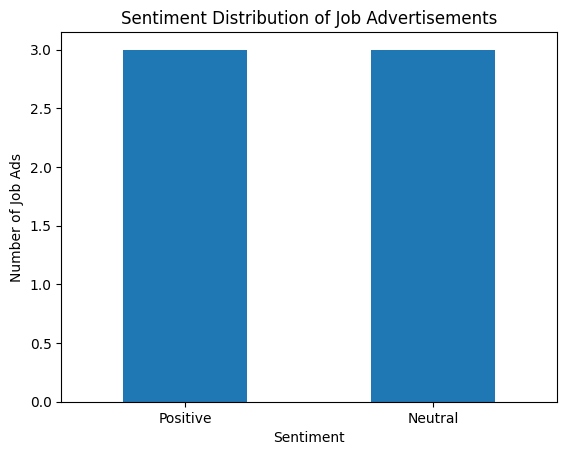

In [31]:
# Present the sentiment results in a bar chart.

df["sentiment_label"].value_counts().plot(kind="bar")

plt.title("Sentiment Distribution of Job Advertisements")
plt.xlabel("Sentiment")
plt.ylabel("Number of Job Ads")
plt.xticks(rotation=0)
plt.show()

### Interpretation of Sentiment Analysis Results

The sentiment analysis shows that the selected job advertisements are either positive or neutral. Three job ads were classified as positive, while the other three were classified as neutral. No job advertisement was classified as negative.

This kind of result is expected because job advertisements are usually written in a professional and attractive way to encourage people to apply. Companies often use positive language to describe responsibilities, teamwork, learning opportunities, benefits, and the work environment. Therefore, the sentiment analysis confirms that the language in the collected job ads is generally positive or neutral rather than negative.

In [34]:
# Save the processed dataset with the new analysis columns.

df.to_excel("processed_job_ads.xlsx", index=False)